In [518]:
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages
from typing import TypedDict , Annotated

from langchain_core.messages import BaseMessage,HumanMessage
from langchain_mistralai import ChatMistralAI
from langchain_community.document_loaders import PyPDFLoader

from langgraph.prebuilt.tool_node import ToolNode,tools_condition
from langchain_community.tools import DuckDuckGoSearchRun
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv

import smtplib
import os
from email.mime.text import MIMEText
from email.mime.multipart import MIMEMultipart
from email.mime.base import MIMEBase
from email import encoders
from pydantic import BaseModel

In [519]:
# load API KEY
load_dotenv()


False

In [520]:
llm = ChatMistralAI()

In [521]:
def extract_resume_text(pdf_path):
    loader = PyPDFLoader(pdf_path)
    text=loader.load()
    text_t="\n".join([text.page_content for text in text])
    return text_t

In [522]:
text = extract_resume_text('AI_DEEPAK_RESUME.pdf') # ye streamlit se call hoga

In [523]:
type(text)

str

In [524]:
class details(BaseModel):
    name:str
    phone:str
    email:str
    github:str
    linkedin:str

In [527]:
class Resume(TypedDict):
    name:str
    phone:str
    email:str
    resume:str
    email:str
    job_description:str
    email_body:str
    message:str
    github_link : str 
    linkedin_link : str

In [528]:
def extreact_details(state:Resume)->Resume:
    llm_with_s = llm.with_structured_output(details)
    response = llm_with_s.invoke(text)
    return{
        "name": response.name,
        "phone": response.phone,
        "github_link": response.github,
        "linkedin_link": response.linkedin
    }

In [529]:
def generate_email_body(state:Resume) -> str:
    
    prompt =f"""
You are a senior Technical Recruiter and expert business email writer.

Your task is to write a highly professional, structured, and personalized job application email body.

JOB DESCRIPTION:
{state['job_description']}

CANDIDATE RESUME:
{state['resume']}

Instructions:

1. Carefully analyze the job description and extract:
   - Core technical skills
   - Key responsibilities
   - Tools/technologies mentioned
   - Type of environment (startup, enterprise, production, etc.)

2. Match the candidate’s most relevant experience and skills directly to those requirements.
   - Do NOT repeat the entire resume.
   - Focus only on the strongest alignment.

3. Email Structure (STRICTLY FOLLOW):

   Paragraph 1:
   - Express interest in the role
   - Mention the company/domain
   - Brief 1-line positioning statement

   Paragraph 2:
   - Highlight 3–5 highly relevant skills/achievements
   - Show impact (performance, scalability, production systems, etc.)
   - Align directly with job requirements

   Paragraph 3:
   - Express enthusiasm for contributing
   - Mention collaboration, ownership, or production mindset
   - Invite further discussion

Rules:
- Start with: 👩‍💼Dear Hiring Manager,
- Do NOT include subject line
- Do NOT include sender/receiver emails
- Keep length between 170–220 words
- Professional, confident, not desperate
- No bullet points
- No placeholders
- End exactly with: Best Regards,

Return ONLY the email body.
"""

    response = llm.invoke(prompt)

    return {'email_body': response.content.strip()}

In [530]:
def send_email_node(state:Resume):
    
    sender_email = "kashyap040098@gmail.com"
    app_password = "pcmx bcnn eahp xhha"  # ⚠️ .env me rakho

    # Create message container
    msg = MIMEMultipart()
    msg["From"] = sender_email
    msg["To"] = state["email"]
    msg["Subject"] = "Job Application - Deepak Kumar"

        # Email Body
    body = f"""
{state["email_body"]}

🔗 Project Links:
Name : {state.get('name')}
Phone No: {state.get('phone')}
GitHub : {state.get('github_link')}
Linkedin : {state.get('linkedin_link')}

Thank you for your time and consideration.
"""
    msg.attach(MIMEText(body, "plain"))

        # Attach PDF Resume
    filename = "AI_DEEPAK_RESUME.pdf"  # 👈 yaha apna pdf file path do

    with open(filename, "rb") as attachment:
        part = MIMEBase("application", "octet-stream")
        part.set_payload(attachment.read())

    encoders.encode_base64(part)

    part.add_header(
        "Content-Disposition",
        f"attachment; filename={os.path.basename(filename)}",
        )

    msg.attach(part)

        # Send Email
    server = smtplib.SMTP("smtp.gmail.com", 587)
    server.starttls()
    server.login(sender_email, app_password)
    server.send_message(msg)
    server.quit()

    return {"message":"sent email"}

In [531]:
graph = StateGraph(Resume)

In [532]:
# Nodes
#graph.add_node("START",START)
graph.add_node('Extreact_Details',extreact_details)
graph.add_node('Email_maker',generate_email_body)
graph.add_node('Send_mail',send_email_node)

# Egde
graph.add_edge(START,'Extreact_Details')
graph.add_edge('Extreact_Details','Email_maker')
graph.add_edge('Email_maker','Send_mail')
graph.add_edge('Send_mail',END)

In [533]:
app = graph.compile()

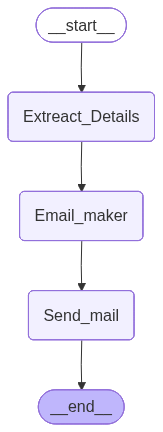

In [534]:
app

In [535]:
app.invoke({'email':'latticevanguard.plg@gmail.com',"job_description":"""Company Description

EdNet Consultants Pvt Ltd is an overseas education consultancy based in New Delhi, India, and has been helping students since 2002. The company provides services such as career counseling, admissions guidance, test prep, visa assistance, and post-admissions guidance. The Director, Niharika Sondhi, believes in recognizing every student's individual requirement and helping them choose the right career path.


Role Description



CANDIDATES FROM DELHI AND NCR SHOULD APPLY:


This is a contract-based part-time hybrid role for a Computer Science Teacher. The job requires the teacher to plan, prepare, and deliver United States college lessons/credits on Software and Computer science. The teacher must be available to teach classes in New Delhi and have the flexibility to work from home. The daily tasks will also include lesson plans, activities, quizzes, testing, grading assignments, providing student feedback, and conducting regular assessments.


Qualifications

· Must have a Master’s degree in Computer Science
· Must possess excellent knowledge of CS as well as software and its related concepts
· Minimally two years of experience teaching or tutoring Computer Science to 1st year-level college students students
· Ability to communicate and deliver lessons effectively in English only
· Experience in lesson planning and creating constructive lesson plans
· Patience, resilience, and the ability to manage students
· Excellent interpersonal and English communication skills
· Ability to work in a multicultural environment
· Experience in teaching overseas education is a plus


Industry

Education Administration Programs
Employment Type

Contract – Part Time 
""",'github_link':'github.com/DEEPAK-KUMAR-SINGH1','linkedin_link':'linkedin.com/in/deepak-kumar-singh-5429aa199/','resume':"""DEEPAK KUMAR SINGH
Artificial Intelligence/Gen AI/Data Science
Email : kashyap040098@gmail.com | Phone: 7303938450
LinkedIn : https://www.linkedin.com/in/deepak-kumar-singh-5429aa199/
GitHub : https://github.com/DEEPAK-KUMAR-SINGH1
Objective
Motivated and detail-oriented BCA student with strong foundations in Artificial Intelligence, Machine
Learning, and Data Science. Skilled in building predictive models, natural language processing, and data
visualization. Seeking an AI Intern role to apply technical expertise, solve real-world problems, and
contribute to innovative projects.
Technical Skills
● Programming: Python, Java, SQL, PHP, HTML, JavaScript
● AI/ML Frameworks: NumPy, Pandas, Scikit-learn, Matplotlib, Seaborn, TensorFlow, Keras,
PyTorch, OpenCV, NLTK, spaCy, Hugging Face Transformers, Streamlit, Gradio, Flask, FastAPI, Gensim,
Pickle, Joblib, Requests, BeautifulSoup, Jupyter Notebook, Google Colab, VS Code, Git, GitHub, Docker,
Langchain, LangGraph, LangSmith
● Core Competencies: Machine Learning, Deep Learning, Natural Language Processing (NLP),
Computer Vision, Neural Networks, Reinforcement Learning, Prompt Engineering, Transfer Learning,
Generative AI (LLMs, GANs), Hyperparameter Tuning, Data Preprocessing, Model Deployment, API
Development
● Databases: MySQL, PostgreSQL, SQLite, MongoDB, Oracle Database, Microsoft SQL Server
● Cloud & Tools: AWS, GCP, Azure, Heroku, MLflow, Weights & Biases, GitHub Actions
Education
● Indira Gandhi National Open University (IGNOU), New Delhi Bachelor of Computer Applications (BCA)
July 2023 – June 2026 (Expected)
Coursework: Programming, Data Structures, Databases, Artificial Intelligence Fundamentals
● Rajdhani College, University of Delhi Affiliated to IGNOU for BCA program
Experience
AI Developer Intern
OneshopAI Pvt. Ltd. – Noida, Uttar Pradesh (Dec 2025 – Feb 2026)
Developed AI-powered applications using Python, FastAPI, and LangChain, integrating LLMs (Mistral/OpenAI
APIs) for chatbot and text generation solutions.
Data Science Intern
Unified Mentor Pvt. Ltd., - Gurgaon, Haryana (May 2025 – January 2026)
Worked on data analysis and machine learning projects using Python, Pandas, NumPy, and Scikit-learn
to build predictive models and extract actionable insights.
Projects : https://github.com/DEEPAK-KUMAR-SINGH1
● Cybersecurity-AI-Chatbot | Live: https://cyberyodha.streamlit.app/
Cybersecurity AI Chatbot 🤖 – An interactive AI assistant that explains cybersecurity concepts
in simple language, provides step-by-step solutions, answers technical queries, and helps
beginners and professionals learn cybersecurity effectively.
● AI Story Generator from Images | Live: https://taleifyai.streamlit.app/
Built an AI-powered web application that converts uploaded images (JPEG/PNG) into creative,
human-like stories by analyzing visual elements, emotions, and context using Computer Vision
and LLMs (Mistral) integrated with LangChain. Developed with Python and Streamlit, featuring
automated storytelling, fast processing, and secure API key management using Dotenv.
● VidSynth AI Chat YouTubeVideo | Live:https://vidsynth.streamlit.app/
Developed an AI-powered web application that converts YouTube videos into structured,
searchable knowledge by fetching transcripts, translating content to English, extracting key
topics, and generating organized notes. Implemented RAG-based semantic search using
LangChain, FAISS/Chroma, and LLMs (OpenAI/Gemini/Mistral) to enable context-aware chat
with videos, built with Python and Streamlit/FastAPI.
● Chat-with-multiple-PDFs – Chat with Multiple PDFs" is an AI-powered RAG system
that lets users query multiple PDF documents at once. It extracts content, retrieves relevant
sections using semantic search, and provides accurate, context-aware answers in a
conversational way.
● Live-Object-Detection-Description-Google-Gemini – An advanced AI-powered
system that captures live video, detects multiple objects in real time, and generates accurate,
human-like descriptions using Google Gemini. Ideal for smart surveillance, fleet monitoring, and
intelligent event-based recording.
Certifications & Virtual Internships : Link
● Deloitte – Data Analytics Insights
Gained hands-on experience in data cleaning, visualization, and data-driven
decision-making.
● Tata Group – Generative AI Experience
Explored Generative AI applications, prompt engineering techniques, and real-world
use cases.
● Amazon – Cloud Workspace Management
Learned to set up and manage virtual desktops using AWS cloud infrastructure.
Languages
● English – Professional Proficiency | Hindi – Native / Full Proficiency"""})

{'name': 'DEEPAK KUMAR SINGH',
 'phone': '7303938450',
 'email': 'latticevanguard.plg@gmail.com',
 'resume': 'DEEPAK KUMAR SINGH\nArtificial Intelligence/Gen AI/Data Science\nEmail : kashyap040098@gmail.com | Phone: 7303938450\nLinkedIn : https://www.linkedin.com/in/deepak-kumar-singh-5429aa199/\nGitHub : https://github.com/DEEPAK-KUMAR-SINGH1\nObjective\nMotivated and detail-oriented BCA student with strong foundations in Artificial Intelligence, Machine\nLearning, and Data Science. Skilled in building predictive models, natural language processing, and data\nvisualization. Seeking an AI Intern role to apply technical expertise, solve real-world problems, and\ncontribute to innovative projects.\nTechnical Skills\n● Programming: Python, Java, SQL, PHP, HTML, JavaScript\n● AI/ML Frameworks: NumPy, Pandas, Scikit-learn, Matplotlib, Seaborn, TensorFlow, Keras,\nPyTorch, OpenCV, NLTK, spaCy, Hugging Face Transformers, Streamlit, Gradio, Flask, FastAPI, Gensim,\nPickle, Joblib, Requests, Be